In [1]:
#Setup Awal
from google.colab import drive, userdata
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/flood-hazard-bandung-bogor')

!git config user.email "emailkamu@gmail.com"
!git config user.name "Nama Kamu"
!git pull origin main

print("✅ Setup selesai")

Mounted at /content/drive
From https://github.com/La01234/flood-hazard-bandung-bogor
 * branch            main       -> FETCH_HEAD
Already up to date.
✅ Setup selesai


In [2]:
#import library
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Library siap")

✅ Library siap


In [3]:
#Load GeoTIFF
CITY = 'bandung'

with rasterio.open(f'data/raw/flood_features_{CITY}.tif') as src:
    data      = src.read()
    profile   = src.profile
    transform = src.transform

band_names = [
    'elevation', 'slope', 'aspect', 'TWI',
    'NDVI', 'MNDWI', 'NDBI',
    'SAR_VV_baseline', 'SAR_change', 'dist_river',
    'permanent_water', 'built_up', 'study_mask', 'flood_label'
]

print(f"Shape data : {data.shape}")
print(f"Resolusi   : {src.res}")
print(f"CRS        : {src.crs}")

Shape data : (14, 492, 722)
Resolusi   : (30.0, 30.0)
CRS        : EPSG:32748


In [4]:
#study mask
idx = {name: i for i, name in enumerate(band_names)}

study_mask = data[idx['study_mask']] == 1

print(f"Total piksel      : {data.shape[1] * data.shape[2]:,}")
print(f"Piksel study area : {study_mask.sum():,}")
print(f"Persentase        : {study_mask.sum() / study_mask.size * 100:.1f}%")

Total piksel      : 355,224
Piksel study area : 528
Persentase        : 0.1%


In [5]:
#reshape ke tabular
X_raw = data[:, study_mask].T   # (n_pixels, 14)

feature_cols = band_names[:-1]  # semua kecuali flood_label
X = X_raw[:, :-1]               # fitur
y = X_raw[:, -1]                # label

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"\nDistribusi label:")
print(f"  Non-banjir (0): {(y==0).sum():,} piksel ({(y==0).mean()*100:.1f}%)")
print(f"  Banjir     (1): {(y==1).sum():,} piksel ({(y==1).mean()*100:.1f}%)")

Shape X : (528, 13)
Shape y : (528,)

Distribusi label:
  Non-banjir (0): 512 piksel (97.0%)
  Banjir     (1): 16 piksel (3.0%)


In [6]:
#cek missing value
df = pd.DataFrame(X, columns=feature_cols)

print("Missing values per fitur:")
print(df.isnull().sum())
print(f"\nTotal missing  : {df.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(df.values).sum()}")

Missing values per fitur:
elevation          0
slope              0
aspect             0
TWI                0
NDVI               0
MNDWI              0
NDBI               0
SAR_VV_baseline    0
SAR_change         0
dist_river         0
permanent_water    0
built_up           0
study_mask         0
dtype: int64

Total missing  : 0
Infinite values: 0


In [7]:
#handle missing & infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df.columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  {col}: diisi median = {median_val:.3f}")

print(f"\n✅ Missing values setelah cleaning: {df.isnull().sum().sum()}")


✅ Missing values setelah cleaning: 0


In [8]:
#statistik deskriptif
print(df.describe().round(3))

       elevation    slope   aspect      TWI     NDVI    MNDWI     NDBI  \
count    528.000  528.000  528.000  528.000  528.000  528.000  528.000   
mean     670.578    3.549  161.068    4.969    0.425   -0.269   -0.127   
std       15.840    3.199  103.434    2.368    0.208    0.182    0.119   
min      659.000    0.000   -0.000    0.849   -0.308   -0.525   -0.426   
25%      664.000    1.868   78.094    3.313    0.257   -0.389   -0.216   
50%      667.000    2.631  158.326    4.123    0.487   -0.321   -0.148   
75%      673.000    3.994  244.789    6.086    0.587   -0.211   -0.032   
max      823.000   23.167  354.247   13.369    0.817    0.620    0.234   

       SAR_VV_baseline  SAR_change  dist_river  permanent_water  built_up  \
count          528.000     528.000     528.000            528.0     528.0   
mean            -9.481       0.111     413.257              0.0       1.0   
std              3.383       1.655     350.205              0.0       0.0   
min            -18.153   

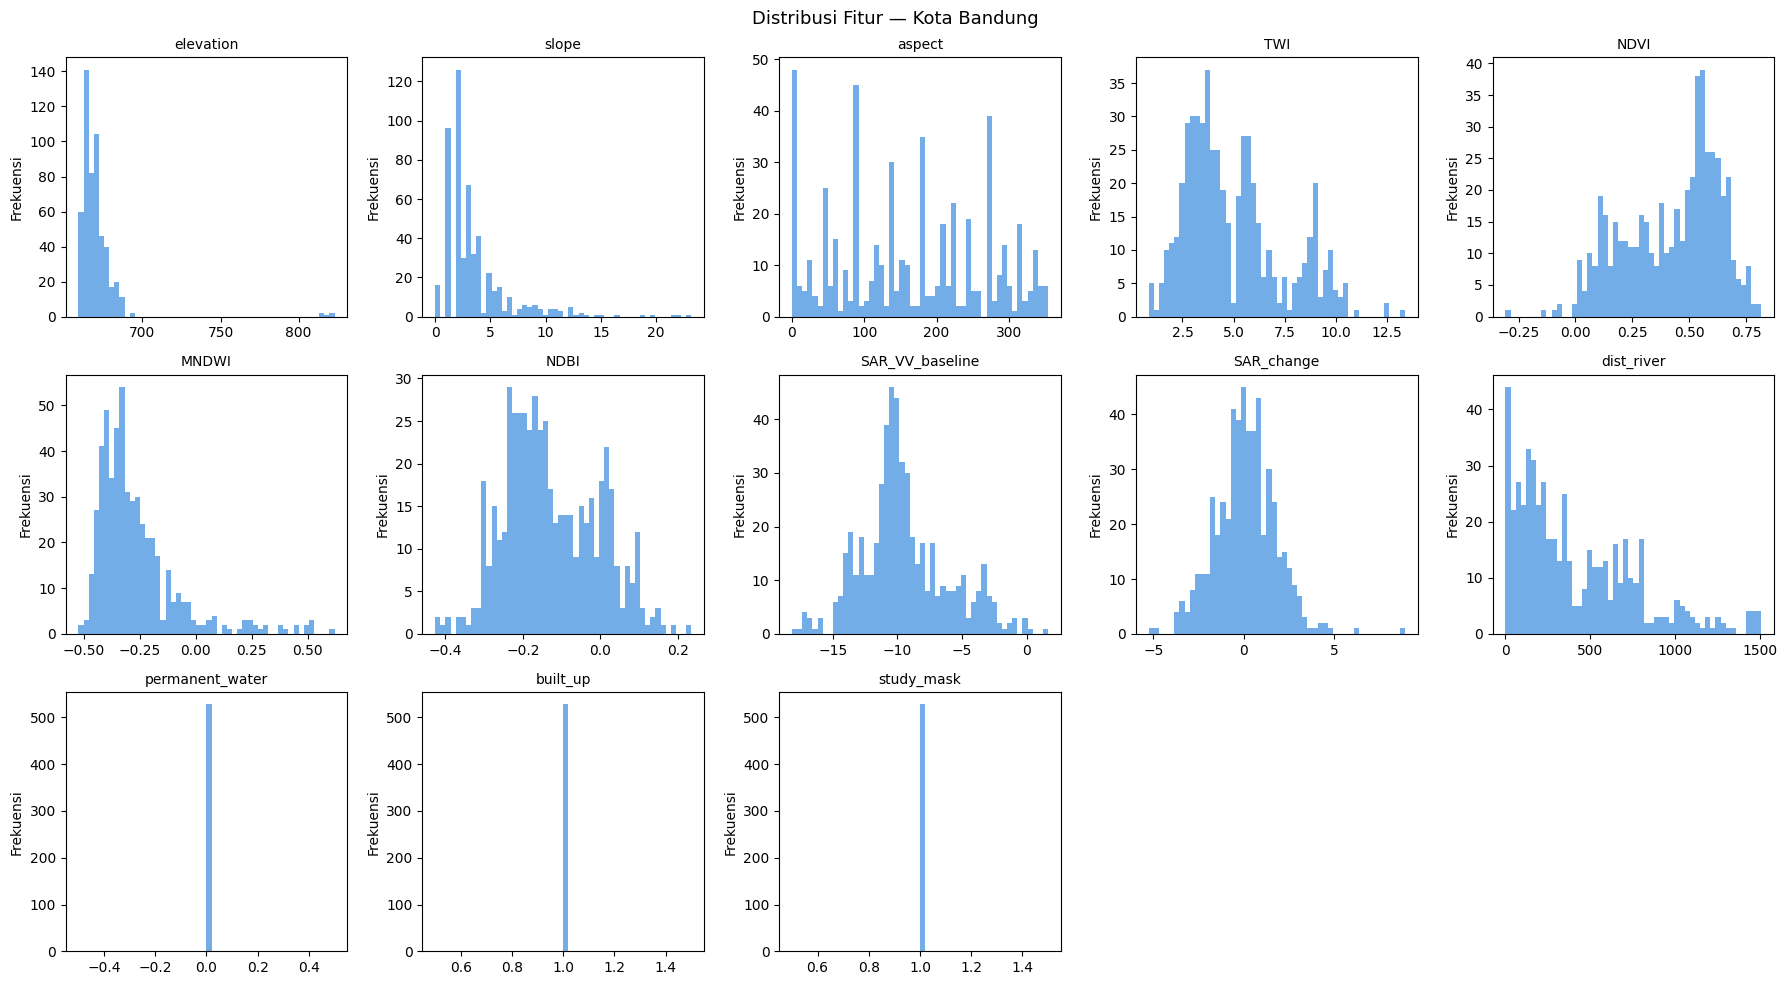

✅ Plot tersimpan


In [9]:
#visualisasi
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=50, color='#378ADD', alpha=0.7, edgecolor='none')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frekuensi')

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Distribusi Fitur — Kota {CITY.title()}', fontsize=13)
plt.tight_layout()
plt.savefig(f'outputs/distribusi_fitur_{CITY}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot tersimpan")

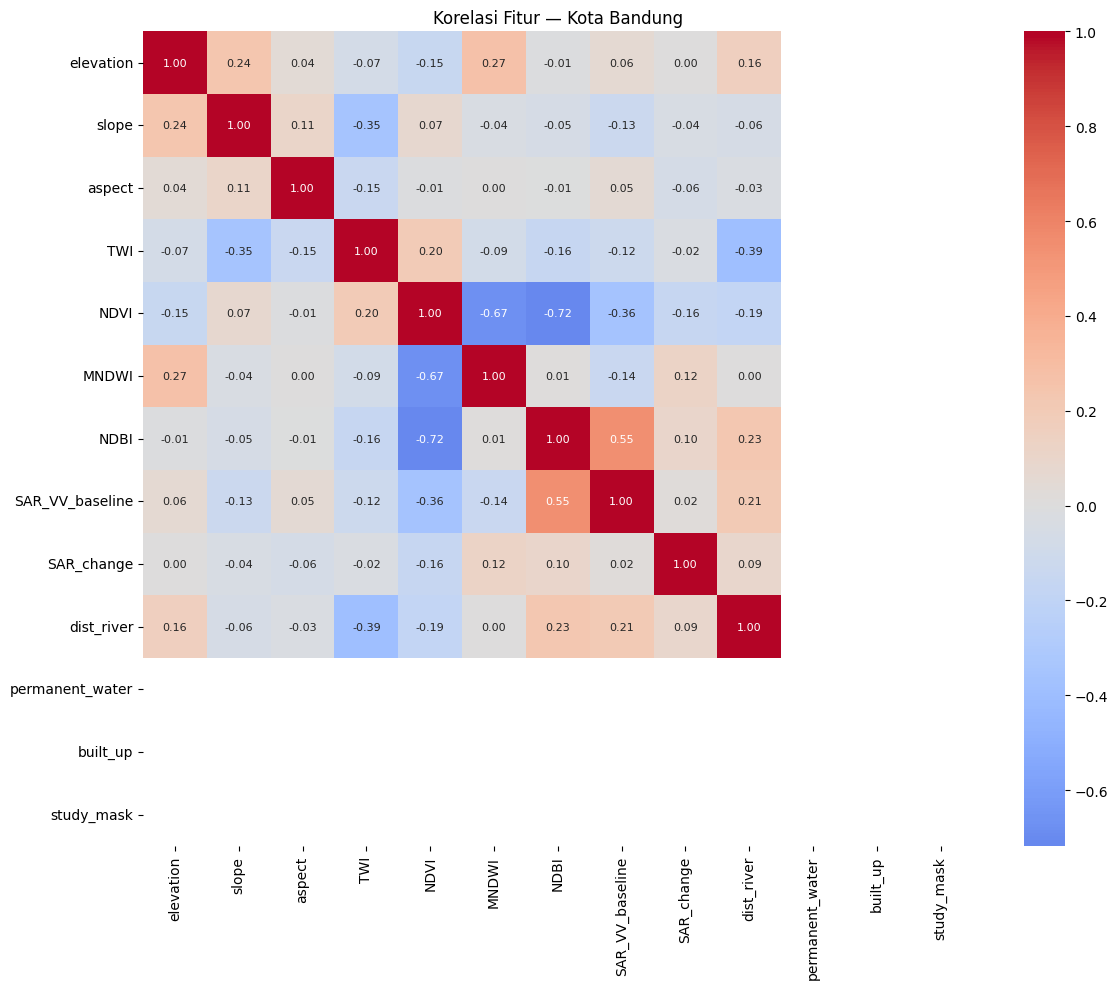

✅ Plot tersimpan


In [10]:
#korelasi antar fitur
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 8})
ax.set_title(f'Korelasi Fitur — Kota {CITY.title()}')
plt.tight_layout()
plt.savefig(f'outputs/korelasi_{CITY}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot tersimpan")

In [11]:
#simpan data bersih
df['flood_label'] = y.astype(int)
df.to_parquet(f'data/processed/features_{CITY}.parquet', index=False)

print(f"✅ Data tersimpan: data/processed/features_{CITY}.parquet")
print(f"   Shape : {df.shape}")
print(f"   Ukuran: {os.path.getsize(f'data/processed/features_{CITY}.parquet')/1e6:.1f} MB")

✅ Data tersimpan: data/processed/features_bandung.parquet
   Shape : (528, 14)
   Ukuran: 0.0 MB
